![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

### Praca z rozkładami prawdopodobieństwa w scipy

 * Rozkłady prawdopodobieństwa są dostępne w module [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html)
 * Rozkłady prawdopodbieństwa można wykorzystywać jako uogólnione obiekty lub jako obiekty z określonymi parametrami (frozen)

### Użycie rozkładu zdefiniowanego w bibliotece scipy.stats

Prawdopodobieństwo, że losowo wybrany klient dokona zakupu nowego samochodu w salonie wynosi $p=0,1$. W ciągu dnia w salonie pojawia się zwykle $n=15$ klientów. Oblicz prawdopodbieństwo, że trzech lub więcej klienów dokona zakupu.
Zakładając, że klienci dokonują zakupu (lub nie) niezaleznie od siebie do rozwiązania zadania można użyć rozkładu [rozkładu dwumianowego](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html#scipy.stats.binom).

**Ładowanie wymaganych bibliotek**

In [1]:
from scipy import stats as st
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

**Definiowanie rozkładu**

In [2]:
n = 15
p = 0.1
rozk_dw = st.binom(n, p)

**Użycie metody pmf do obliczenia prawdopodobieństwa**

In [3]:
P = sum(rozk_dw.pmf(range(3,n+1)))
print("Prawdopodobieństwo wynosi P={}".format(P))

Prawdopodobieństwo wynosi P=0.18406106910639175


**Wykres funkcji prawdopodobieństwa i dystrybuanty**

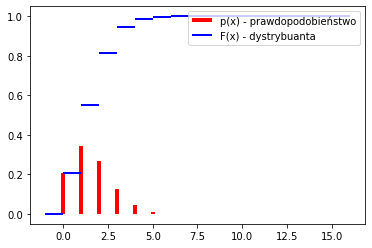

In [4]:
xk = np.array(range(0,n+1))
p = rozk_dw.pmf(xk)
F = rozk_dw.cdf(xk)
plt.vlines(xk, 0, p, colors='r', lw=4)
plt.hlines(np.append([0],F), np.append([min(xk)-1],xk), np.append(xk,[max(xk)+1]), colors='b', lw=2)
plt.legend(["p(x) - prawdopodobieństwo", "F(x) - dystrybuanta"])
pass

**Losowanie liczb z danego rozkładu**

In [5]:
x = rozk_dw.rvs(size=100)
x

array([2, 2, 0, 2, 0, 3, 0, 1, 3, 3, 3, 2, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 1, 3, 1, 1, 1, 1, 3, 5, 0, 1, 1, 1, 2, 3, 1, 1, 4, 0, 4, 1, 2,
       0, 2, 1, 1, 3, 2, 1, 3, 0, 4, 0, 1, 0, 1, 1, 1, 1, 3, 0, 2, 2, 2,
       2, 4, 2, 3, 5, 1, 0, 1, 4, 0, 2, 1, 0, 1, 1, 3, 3, 1, 0, 4, 3, 1,
       1, 1, 2, 3, 1, 3, 1, 3, 2, 1, 1, 0])

### Definiowanie własnego rozkładu

Narysować wykres rozkładu prawdopodobieństwa i dystrybuanty zmiennej losowej $X$, dla której: $P(X=0)=\frac{1}{10}$,  $P(X=1)=\frac{9}{10}$. Obliczyć jej wartość oczekiwaną, wariancję i odchylenie standardowe.

W module scipy znajduje się obiekt rv_discrete, który można wykorzystać do definiowania własnego dyskretnego rozkładu prawdopodobieństwa. W celu pracy z rozkładem wystarczy użyć wbudowanych metod np. expect obliczy wartość oczekiwaną.

In [6]:
rozklad = st.rv_discrete(name='Rozkład', values=((0,1), (1/10,9/10)))

In [7]:
E = rozklad.expect() # wartość oczekiwana
E

0.9

In [8]:
S = rozklad.std() # odchylenie standardowe
S

0.29999999999999993

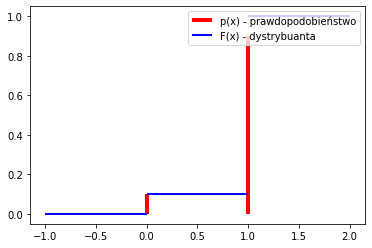

In [9]:
xk=rozklad.xk
p = rozklad.pmf(xk)
F = rozklad.cdf(xk)
plt.vlines(xk, 0, p, colors='r', lw=4)
plt.hlines(np.append([0],F), np.append([min(xk)-1],xk), np.append(xk,[max(xk)+1]), colors='b', lw=2)
plt.legend(["p(x) - prawdopodobieństwo", "F(x) - dystrybuanta"])
pass

**Losowanie liczb z danego rozkładu**

In [10]:
x = rozklad.rvs(size=100)
x

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1])